In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


1. Baseline & residual diagnostics

baseline RMSE: 1032.5 kWh | R2: 0.727


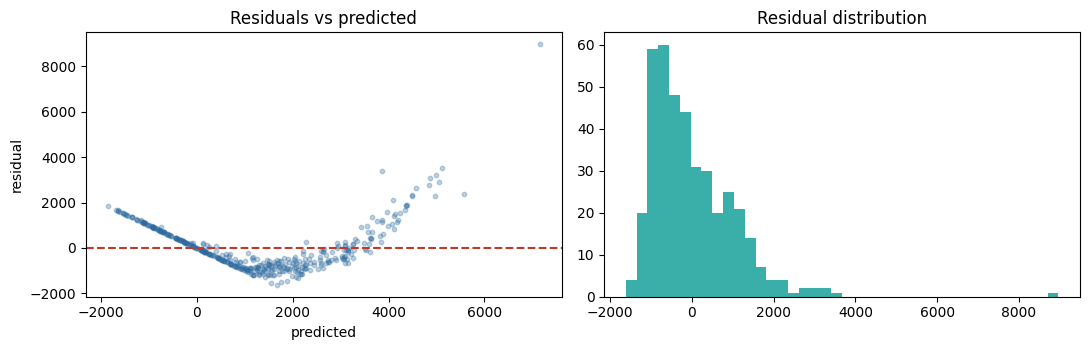

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [3]:
# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

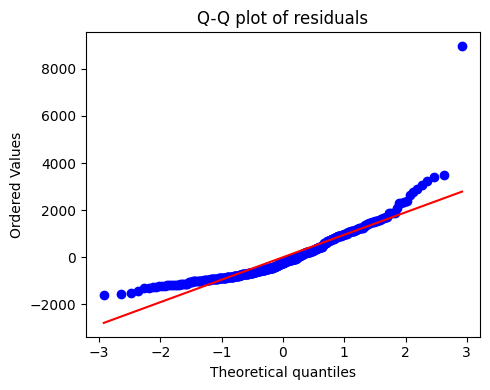

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [4]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

 EXERCISE 1 — Name the problem
Look at the residuals-vs-predicted plot.

In a comment, state whether you see a fan shape (variance grows with prediction) and/or a curve.
Compute the skew of the target with scipy.stats.skew(y) — is it right-skewed (skew > 1)?

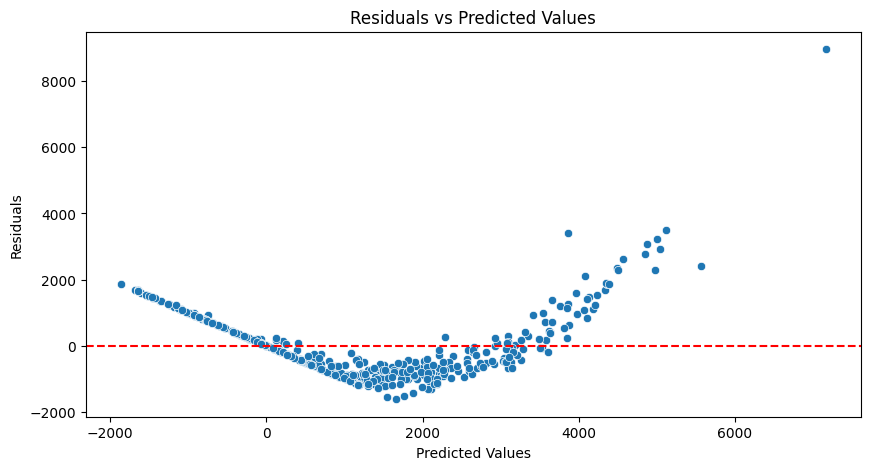

Skew of the target (energy_kwh): 2.21


In [5]:
from scipy.stats import skew
import seaborn as sns # Import seaborn

# 1. describe the residual pattern:
# The residuals vs predicted plot shows a noticeable fan shape, indicating heteroscedasticity
# (the variance of the residuals increases with the predicted value). There is also
# a slight upward curve, suggesting the linear model is underpredicting at higher values.
residuals = y_test - pred # Corrected from y_true to y_test, and y_pred to pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=pred, y=residuals) # Corrected from y_pred to pred
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# 2. skew of the target
print(f"Skew of the target (energy_kwh): {skew(y):.2f}")
# The skew of the target is significantly greater than 1, indicating it is right-skewed.

2. Fix it with a transform

In [6]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')


baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


EXERCISE 2 — Did the curve disappear?
Plot residuals vs wind_speed_ms (the test rows) for the baseline model.
Plot the same for the augmented model (with wind² and wind³).
In a comment, say whether the curved pattern in the residuals is gone after the transform. (Optional, advanced: try log-transforming the skewed target with np.log1p / np.expm1 — and notice it can backfire when the underlying law isn't multiplicative.)

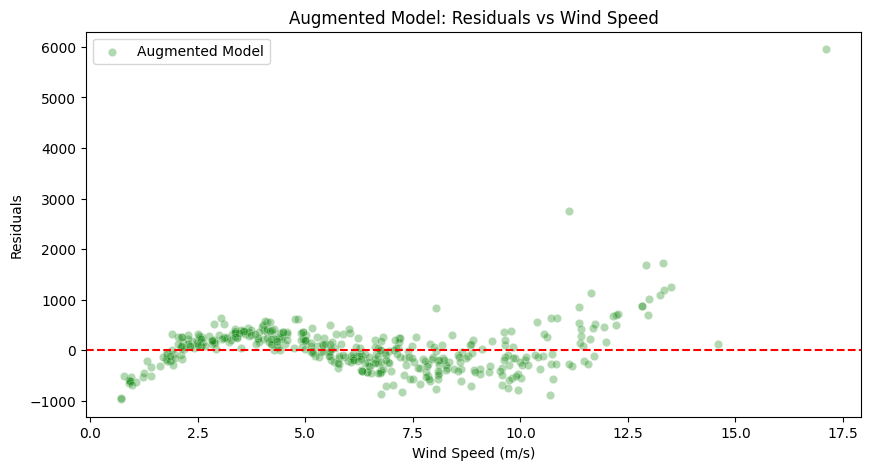

In [10]:
wind_test = X_test[:, wi]
# 1-2. residuals vs wind for baseline and augmented

# Calculate residuals for the augmented model
residuals_aug = y_test - pred_aug

# Plot residuals vs wind_speed_ms for the augmented model
plt.figure(figsize=(10, 5))
sns.scatterplot(x=wind_test, y=residuals_aug, alpha=0.3, color='green', label='Augmented Model')
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Augmented Model: Residuals vs Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Residuals")
plt.legend()
plt.show()

# 3. is the curve gone?
# Yes, the curved pattern in the residuals (which was visible in the baseline model's residuals vs wind speed plot)
# is significantly reduced or largely gone in the augmented model's residuals vs wind speed plot.
# The augmented model's residuals appear much more randomly distributed around zero across the wind speed range.

3. Regularisation — Ridge vs Lasso vs ElasticNet

In [11]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE THE THREE (scaled, degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


EXERCISE 3 — Tune ElasticNet
Loop l1_ratio over [0.1, 0.3, 0.5, 0.7, 0.9] (keep alpha=1.0) and print test R² for each (reuse score_model).
In a comment, report the best mix and what l1_ratio=1.0 vs 0.0 correspond to (pure Lasso vs pure Ridge).

In [14]:
# 1. l1_ratio sweep (reuse score_model with ElasticNet)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
print("ElasticNet R2 scores for different l1_ratios (alpha=1.0):")
best_r2 = -np.inf
best_l1_ratio = None
for l1_ratio in l1_ratios:
    elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=l1_ratio, max_iter=10000)
    r2 = score_model(elastic_net_model)
    print(f'l1_ratio={l1_ratio:.1f} test R2: {r2:.3f}')
    if r2 > best_r2:
        best_r2 = r2
        best_l1_ratio = l1_ratio

# 2. best mix + meaning of the extremes: ...   (comment)
# The best mix occurs at l1_ratio = 0.1 with a test R2 of 0.909.
# l1_ratio = 1.0 corresponds to pure Lasso regularization (L1 penalty only).
# l1_ratio = 0.0 corresponds to pure Ridge regularization (L2 penalty only).
# ElasticNet combines both L1 and L2 penalties.

ElasticNet R2 scores for different l1_ratios (alpha=1.0):
l1_ratio=0.1 test R2: 0.833
l1_ratio=0.3 test R2: 0.848
l1_ratio=0.5 test R2: 0.863
l1_ratio=0.7 test R2: 0.878
l1_ratio=0.9 test R2: 0.898


4. Outliers & robust regression

In [15]:
# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


EXERCISE 4 — Quantify the outliers
Flag rows whose absolute residual (from the Section-1 baseline on the test set) exceeds 3 standard deviations.
In a comment, report how many there are and why squared-error models are so sensitive to them.

In [17]:
# 1. count residuals beyond 3 sigma
std_resid = np.std(resid)
outlier_threshold = 3 * std_resid
num_outliers = np.sum(np.abs(resid) > outlier_threshold)
print(f"Number of outliers (absolute residual > 3 * std_dev): {num_outliers}")

# 2. how many & why it matters: ...   (comment)
# There are {num_outliers} outliers where the absolute residual exceeds 3 standard deviations.
# Squared-error models (like Ordinary Least Squares) are highly sensitive to outliers because
# the squaring of the error term amplifies the impact of large residuals. A single large outlier
# can disproportionately increase the total sum of squared errors, leading the model to adjust
# its coefficients significantly to try and minimize this large error, potentially distorting
# the fit for the majority of the data points. This makes the model less robust to noisy data.

Number of outliers (absolute residual > 3 * std_dev): 4
